In [5]:

import pandas as pd
import numpy as np


In [6]:

data = pd.read_csv("data/prepared_reviews_data.csv")
data.head(5)


,log_usefulness,Age,Rating,Recommended IND,pred_relevance,pred_sentiment_score,pred_has_fit_info,pred_has_size_info,pred_has_comfort_info,pred_has_material_info,...,Class Name_Pants,Class Name_Shorts,Class Name_Skirts,Class Name_Sleep,Class Name_Sweaters,Class Name_Swim,Class Name_Trend,Positive Feedback Count,Mean Positive Feedback Count,Clothing ID
0,0.215140,34,5,1,1.000000,98.030396,9.996808e-01,1.000000e+00,3.693655e-05,0.000004,...,False,False,False,False,False,False,False,4,3.032143,1080
1,-1.237212,60,3,0,1.000000,54.821026,9.999049e-01,9.999975e-01,9.997002e-01,0.001643,...,False,False,False,False,False,False,False,0,2.445993,1077
2,-1.361803,50,5,1,0.012738,98.573210,2.842368e-08,7.393026e-09,9.207025e-04,0.000002,...,True,False,False,False,False,False,False,0,2.903226,1049
3,0.215140,49,2,0,1.000000,10.083105,4.273405e-03,1.000000e+00,1.756544e-09,0.000080,...,False,False,False,False,False,False,False,4,3.032143,1080
4,-0.421213,39,5,1,1.000000,98.897010,2.391771e-04,1.000000e+00,2.720618e-05,0.000014,...,False,False,False,False,False,False,False,1,2.047619,858


Заметим, что бинарные переменные в булевом формате, преобразуем

In [7]:

bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)
data.head(5)


,log_usefulness,Age,Rating,Recommended IND,pred_relevance,pred_sentiment_score,pred_has_fit_info,pred_has_size_info,pred_has_comfort_info,pred_has_material_info,...,Class Name_Pants,Class Name_Shorts,Class Name_Skirts,Class Name_Sleep,Class Name_Sweaters,Class Name_Swim,Class Name_Trend,Positive Feedback Count,Mean Positive Feedback Count,Clothing ID
0,0.215140,34,5,1,1.000000,98.030396,9.996808e-01,1.000000e+00,3.693655e-05,0.000004,...,0,0,0,0,0,0,0,4,3.032143,1080
1,-1.237212,60,3,0,1.000000,54.821026,9.999049e-01,9.999975e-01,9.997002e-01,0.001643,...,0,0,0,0,0,0,0,0,2.445993,1077
2,-1.361803,50,5,1,0.012738,98.573210,2.842368e-08,7.393026e-09,9.207025e-04,0.000002,...,1,0,0,0,0,0,0,0,2.903226,1049
3,0.215140,49,2,0,1.000000,10.083105,4.273405e-03,1.000000e+00,1.756544e-09,0.000080,...,0,0,0,0,0,0,0,4,3.032143,1080
4,-0.421213,39,5,1,1.000000,98.897010,2.391771e-04,1.000000e+00,2.720618e-05,0.000014,...,0,0,0,0,0,0,0,1,2.047619,858


Выделим предикторы и таргет, поделим датасет на валидационную, тренировочную, тестовую выборки

In [8]:

from sklearn.model_selection import train_test_split

good_counts = data["Clothing ID"].value_counts()
valid_goods = good_counts[good_counts > 50].index

data = data[data["Clothing ID"].isin(valid_goods)].reset_index(drop=True)

X = data.copy().drop(["Clothing ID", "Positive Feedback Count", "Mean Positive Feedback Count", "log_usefulness"], axis=1)
ids = data["Clothing ID"]
y = data["log_usefulness"]

X_train_val, X_test, y_train_val, y_test, ids_train_val, ids_test = train_test_split(X, y, ids, test_size=0.15, random_state=66)
X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(X_train_val, y_train_val, ids_train_val, test_size=0.15 / 0.85, random_state=66)


Выделим и стандартизиурем непрерывные признаки

In [9]:

X_train.columns


Index(['Age', 'Rating', 'Recommended IND', 'pred_relevance',
       'pred_sentiment_score', 'pred_has_fit_info', 'pred_has_size_info',
       'pred_has_comfort_info', 'pred_has_material_info',
       'pred_has_quality_info', 'pred_has_color_info', 'pred_has_type_info',
       'Has Title', 'Title Length', 'Review Length', 'Division Name_General',
       'Division Name_General Petite', 'Division Name_Initmates',
       'Department Name_Bottoms', 'Department Name_Dresses',
       'Department Name_Intimate', 'Department Name_Jackets',
       'Department Name_Tops', 'Department Name_Trend', 'Class Name_Blouses',
       'Class Name_Dresses', 'Class Name_Fine gauge', 'Class Name_Intimates',
       'Class Name_Jackets', 'Class Name_Jeans', 'Class Name_Knits',
       'Class Name_Layering', 'Class Name_Legwear', 'Class Name_Lounge',
       'Class Name_Outerwear', 'Class Name_Pants', 'Class Name_Shorts',
       'Class Name_Skirts', 'Class Name_Sleep', 'Class Name_Sweaters',
       'Class Name_Swi

In [10]:

from sklearn.preprocessing import StandardScaler

continuous = ['Age', 'Rating', 'pred_relevance',
       'pred_sentiment_score', 'pred_has_fit_info', 'pred_has_size_info',
       'pred_has_comfort_info', 'pred_has_material_info',
       'pred_has_quality_info', 'pred_has_color_info', 'pred_has_type_info',
       'Title Length', 'Review Length']
binary = [col for col in X_train.columns if col not in continuous]

scaler = StandardScaler()
X_train[continuous] = scaler.fit_transform(X_train[continuous])
X_val[continuous] = scaler.transform(X_val[continuous])
X_test[continuous] = scaler.transform(X_test[continuous])


Сохраним данные для воспроизводимости:

In [11]:

train_to_save = X_train.copy()
train_to_save["log_usefulness"] = y_train.values
test_to_save = X_test.copy()
test_to_save["log_usefulness"] = y_test.values
val_to_save = X_val.copy()
val_to_save["log_usefulness"] = y_val.values

train_to_save.to_csv("artifacts_tabular_data/train.csv", index=False)
test_to_save.to_csv("artifacts_tabular_data/test.csv", index=False)
val_to_save.to_csv("artifacts_tabular_data/val.csv", index=False)


Также для воспроизводимости зафиксируем seed

In [12]:

import random, os
import torch
import torch.nn as nn

def seed_everything(seed):
  random.seed(seed)
  os.environ["PYTHONHASHSEED"] = str(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)

seed_everything(66)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")


Зафиксируем кол-во эпох, размер тренировочного и тестового/валидационного батчей, терпение перед ренней остановкой (сколько эпох ждем улучшения функции потерь), параметры для логгирования экспериментов с помощью mlflow

In [13]:

class CFG:
  seed = 66
  max_epochs = 60
  train_batch_size = 256
  test_batch_size = 1024
  main_experiment = "tabular_fcn_usefulness"
  tuning_experiment = "tabular_fcn_tuning"
  tracking_uri = "sqlite:////content/mlflow.db"


Создаем класс датасета в формате, с которым работает torch, и оборачиваем в него наши данные

In [14]:

from torch.utils.data import Dataset, DataLoader

class DS(Dataset):

  def __init__(self, X, y):
    self.X = torch.tensor(X.values).float()
    self.y = torch.tensor(y.values).reshape(-1, 1).float()

  def __len__(self):
    return len(self.y)

  def __getitem__(self, i):
    return self.X[i], self.y[i]

val = DS(X_val, y_val)
train = DS(X_train, y_train)
test = DS(X_test, y_test)

val_loader = DataLoader(val, batch_size = CFG.test_batch_size, shuffle=False)
train_loader = DataLoader(train, batch_size = CFG.train_batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size = CFG.test_batch_size, shuffle=False)


Создаем класс полносвязной нейронной сети, тут мы можем редактировать кол-во входных параметров, размер и кол-во скрытых слоев, функцию активации, включать/выключать Dropout - регуляризацию отключением случайных нейронов и BatchNorm - нормализацию данных между слоями

In [15]:

class customFCN(nn.Module):

  def __init__(self, in_dim, hidden_sizes, activation=nn.ReLU, dropout=None, batchnorm=False):

    super().__init__()
    layers = []
    prev = in_dim

    for hidden_size in hidden_sizes:
      layers.append(nn.Linear(prev, hidden_size))
      if batchnorm:
        layers.append(nn.BatchNorm1d(hidden_size))
      layers.append(activation())
      if dropout is not None:
        layers.append(nn.Dropout(dropout))
      prev = hidden_size

    layers.append(nn.Linear(prev, 1))
    self.net = nn.Sequential(*layers)

  def forward(self, X):
    return self.net(X)



Напишем функцию, обучающуюю одну эпоху и возвращающую средниый лосс:

In [16]:

def train_one_epoch(model, loader, optimizer, criterion):
  model.train()
  total = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    loss = criterion(model(x), y)
    loss.backward()
    optimizer.step()
    total += loss.item() * x.size(0)
  return total / len(loader.dataset)


Теперь напишем функцию возвращающую предсказание:

In [17]:

def predict(model, loader):
  model.eval()
  preds = []
  trues = []
  with torch.no_grad():
    for x, y in loader:
      preds.extend(model(x.to(device)).cpu().numpy().reshape(-1))
      trues.extend(y.numpy().reshape(-1))

  return np.array(preds), np.array(trues)



И наконец функцию считающую по предсказанию метрики, помимо метрик ошибок добавим:

* ранговую корреляцию Спирмена тк у нас по сути задача ранжирования отзывов,
* попарное сравнение неравных рангов, тк корреляция Спиремна учитывает отзывы с одинаковым фидбеком, что ухудшает показатель и не дает полную картину
* долю полезных отзывов в топ 10% (полкзными будем считать топ 25% в изначальной выборке)

In [18]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import spearmanr

def mean_correlation(y_true, y_pred, ids):

  pred_w_ids = pd.DataFrame({
      "id": ids,
      "true value": y_true,
      "prediction": y_pred,
  })

  corrs = []
  for _, good in pred_w_ids.groupby("id"):
    if len(good) < 2 or good["true value"].nunique() < 2:
      continue
    corr = spearmanr(good["true value"], good["prediction"]).correlation
    corrs.append(corr)

  return np.mean(corrs)


def pair_accuracy(y_true, y_pred, ids):

  pred_w_ids = pd.DataFrame({
    "id": ids,
    "true value": y_true,
    "prediction": y_pred,
  })

  good_scores = []

  for _, good in pred_w_ids.groupby("id"):
    true = good["true value"].tolist()
    pred = good["prediction"].tolist()

    correct = 0
    total = 0

    for i in range(len(good)):
      for j in range(i + 1, len(good)):
        if true[i] == true[j]:
          continue

        total += 1
        if (true[i] > true[j]) == (pred[i] > pred[j]):
          correct += 1

    if total > 0:
      good_scores.append(correct / total)

  return np.mean(good_scores)


def top_recall(y_true, y_pred, ids):

  pred_w_ids = pd.DataFrame({
    "id": ids,
    "true value": y_true,
    "prediction": y_pred,
  })

  good_scores = []

  for _, good in pred_w_ids.groupby("id"):
    if len(good) < 50:
      continue

    top10 = int(np.ceil(len(good)*0.1))
    top25 = int(np.ceil(len(good)*0.25))
    real_top25 = good.sort_values("true value", ascending=False).head(top25)
    pred_top10 = good.sort_values("prediction", ascending=False).head(top10)

    matches = 0
    for idx in real_top25.index.tolist():
      if idx in pred_top10.index.tolist():
        matches += 1

    good_scores.append(matches/top10)

  return np.mean(good_scores)


def metrics(y_true, y_pred, ids):
  return {
      "mse": mean_squared_error(y_true, y_pred),
      "rmse": root_mean_squared_error(y_true, y_pred),
      "mae": mean_absolute_error(y_true, y_pred),
      "r2": r2_score(y_true, y_pred),
      "corr": mean_correlation(y_true, y_pred, ids),
      "pair_acc": pair_accuracy(y_true, y_pred, ids),
      "top_recall": top_recall(y_true, y_pred, ids)
  }

def evaluate(model, loader, ids):
  y_pred, y_true = predict(model, loader)
  return metrics(y_true, y_pred, ids), y_pred, y_true


Настраиваем треккинг:

In [19]:
!pip install mlflow -q
import mlflow

mlflow.set_tracking_uri(CFG.tracking_uri)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.

Теперь подберем на валидационной выборке гиперпараметры скоркости обучения и силу L2-регуляризции

In [20]:

def validate(hidden_sizes, lr, weight_decay, epochs, patience, dropout, batchnorm,
             activation):

  seed_everything(CFG.seed)
  model = customFCN(42, hidden_sizes, activation, dropout, batchnorm).to(device)
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
  best_loss = float('inf')
  wait = 0

  for _ in range(epochs):
    train_one_epoch(model, train_loader, optimizer, nn.MSELoss())
    m, _, _ = evaluate(model, val_loader, ids_val)

    if m["rmse"] < best_loss - 10**-7:
      best_loss = m["rmse"]
      wait = 0
    else:
      wait += 1

    if wait >= patience:
      break

  return best_loss


hs = [128, 64, 32]
epochs = 25
lrs = [10**-2, 10**-3, 10**-4]
wds = [0, 10**-2, 10**-3, 10**-4]

mlflow.set_experiment(CFG.tuning_experiment)
tune_rows = []

for lr in lrs:
  for wd in wds:
    with mlflow.start_run(run_name=f'lr: {lr}, weight_decay: {wd}'):
      loss = validate(hs, lr, wd, epochs, 5, 0.2, False, nn.ReLU)
      mlflow.log_params({
          "phase": "tuning",
          "hidden_layers": hs,
          "lr": lr,
          "weight_decay": wd,
          "epochs": epochs
      }),
      mlflow.log_metric("rmse", loss)
    tune_rows.append({"lr": lr, "weight_decay": wd, "rmse": loss})


2026/06/14 23:31:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/14 23:31:52 INFO mlflow.store.db.utils: Updating database tables
2026/06/14 23:31:56 INFO mlflow.tracking.fluent: Experiment with name 'tabular_fcn_tuning' does not exist. Creating a new experiment.


In [21]:

tune_rows


[{'lr': 0.01, 'weight_decay': 0, 'rmse': 0.8872745037078857},
 {'lr': 0.01, 'weight_decay': 0.01, 'rmse': 0.8869336843490601},
 {'lr': 0.01, 'weight_decay': 0.001, 'rmse': 0.8864554762840271},
 {'lr': 0.01, 'weight_decay': 0.0001, 'rmse': 0.8859351277351379},
 {'lr': 0.001, 'weight_decay': 0, 'rmse': 0.885839581489563},
 {'lr': 0.001, 'weight_decay': 0.01, 'rmse': 0.8859303593635559},
 {'lr': 0.001, 'weight_decay': 0.001, 'rmse': 0.8858012557029724},
 {'lr': 0.001, 'weight_decay': 0.0001, 'rmse': 0.8857352137565613},
 {'lr': 0.0001, 'weight_decay': 0, 'rmse': 0.8868287205696106},
 {'lr': 0.0001, 'weight_decay': 0.01, 'rmse': 0.8868106603622437},
 {'lr': 0.0001, 'weight_decay': 0.001, 'rmse': 0.8868387937545776},
 {'lr': 0.0001, 'weight_decay': 0.0001, 'rmse': 0.8868287205696106}]

Рассмотрим еще значения

In [22]:

lrs = [3*10**-2, 7*10**-3, 3*10**-3]
wds = [0, 10**-2, 10**-3, 10**-4]

for lr in lrs:
  for wd in wds:
    with mlflow.start_run(run_name=f'lr: {lr}, weight_decay: {wd}'):
      loss = validate(hs, lr, wd, epochs, 5, 0.2, False, nn.ReLU)
      mlflow.log_params({
          "phase": "tuning",
          "hidden_layers": hs,
          "lr": lr,
          "weight_decay": wd,
          "epochs": epochs
      }),
      mlflow.log_metric("rmse", loss)
    tune_rows.append({"lr": lr, "weight_decay": wd, "rmse": loss})



/tmp/ipykernel_19505/2400802014.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(good["true value"], good["prediction"]).correlation
/tmp/ipykernel_19505/2400802014.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(good["true value"], good["prediction"]).correlation
/tmp/ipykernel_19505/2400802014.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(good["true value"], good["prediction"]).correlation
/tmp/ipykernel_19505/2400802014.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(good["true value"], good["prediction"]).correlation
/tmp/ipykernel_19505/2400802014.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(good["true value"], good["predic

In [23]:

tune_rows.sort(key=lambda x: x["rmse"])
tune_rows


[{'lr': 0.001, 'weight_decay': 0.0001, 'rmse': 0.8857352137565613},
 {'lr': 0.001, 'weight_decay': 0.001, 'rmse': 0.8858012557029724},
 {'lr': 0.001, 'weight_decay': 0, 'rmse': 0.885839581489563},
 {'lr': 0.001, 'weight_decay': 0.01, 'rmse': 0.8859303593635559},
 {'lr': 0.01, 'weight_decay': 0.0001, 'rmse': 0.8859351277351379},
 {'lr': 0.003, 'weight_decay': 0.0001, 'rmse': 0.886399507522583},
 {'lr': 0.01, 'weight_decay': 0.001, 'rmse': 0.8864554762840271},
 {'lr': 0.003, 'weight_decay': 0, 'rmse': 0.8864926695823669},
 {'lr': 0.003, 'weight_decay': 0.01, 'rmse': 0.8865174651145935},
 {'lr': 0.003, 'weight_decay': 0.001, 'rmse': 0.8865242004394531},
 {'lr': 0.007, 'weight_decay': 0.01, 'rmse': 0.8866834044456482},
 {'lr': 0.007, 'weight_decay': 0, 'rmse': 0.8867833614349365},
 {'lr': 0.0001, 'weight_decay': 0.01, 'rmse': 0.8868106603622437},
 {'lr': 0.0001, 'weight_decay': 0, 'rmse': 0.8868287205696106},
 {'lr': 0.0001, 'weight_decay': 0.0001, 'rmse': 0.8868287205696106},
 {'lr': 0.00

Получаем лучшее качество при гиперпараметрах lr = 0.001, weight_dacay = 0.0001

In [24]:

best_lr = 10**-3
best_wd = 10**-4


Гиперпараметры подобраны, теперь сравним несколько нейросетей-кандидатов и выберем лучшую, для этого напишем универсальную фунцию для тренировки и оценки нейросеток с подробными настройками

В ней можно настраивать кол-во и размер скрытых слоев, функцию активации, дропаут-регуляризацию, батч-нормализацию, выбор оптимизатора (Adam/AdamW), scheduler (настройку шага обучения), функцию ошибки, силу регуляризации, критерий ранней остановки

In [25]:

import copy
import matplotlib.pyplot as plt

with mlflow.start_run(run_name = "dataset"):
  mlflow.log_artifact("artifacts_tabular_data/train.csv", artifact_path="data")
  mlflow.log_artifact("artifacts_tabular_data/test.csv", artifact_path="data")
  mlflow.log_artifact("artifacts_tabular_data/val.csv", artifact_path="data")


def evaluate_candidate(run_name, hidden_layers, activation, dropout, batchnorm, optimizer_name, scheduler_flg, criterion, lr, wd, early_stopping_patience=None):

  seed_everything(66)
  model = customFCN(42, hidden_layers, activation, dropout, batchnorm).to(device)

  if optimizer_name == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
  else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

  if scheduler_flg:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

  loss_history = {
      "train_loss": [],
      "val_loss": []
  }

  with mlflow.start_run(run_name = run_name):
    mlflow.log_params({
        "hidden_layers": hidden_layers,
        "n_params": sum( params.nelement() for params in model.parameters() ),
        "activation": activation.__name__,
        "dropout": dropout,
        "batchnorm": batchnorm,
        "optimizer": optimizer_name,
        "scheduler": "plateau" if scheduler_flg else None,
        "weight_decay": wd,
        "learning_rate": lr,
        "early_stopping_patience": early_stopping_patience,
        "batch_size": CFG.train_batch_size,
        "max_epochs": CFG.max_epochs
    })

    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    wait = 0

    for epoch in range(1, CFG.max_epochs+1):

      train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
      val_metrics, val_pred, val_true = evaluate(model, val_loader, ids_val.tolist())
      val_loss = val_metrics["mse"]
      loss_history["train_loss"].append(train_loss)
      loss_history["val_loss"].append(val_loss)

      mlflow.log_metric("train_loss", train_loss, step=epoch)
      mlflow.log_metric("val_loss", val_loss, step=epoch)

      if scheduler_flg:
        scheduler.step(val_loss)

      if val_loss < best_val_loss - 10**-6:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
      else:
        wait += 1
        if early_stopping_patience is not None and wait >= early_stopping_patience:
          break

    if best_state is not None:
      model.load_state_dict(best_state)

    mlflow.log_metric("best_epoch", best_epoch)
    mlflow.pytorch.log_model(model, name=run_name)

    model_metrics = {}
    samples = [ ["train", train_loader, ids_train], ["test", test_loader, ids_test], ["val", val_loader, ids_val] ]
    for name, loader, ids in samples:
      metrics, _, _ = evaluate(model, loader, ids)
      for metric in metrics:
        if name == "train" and metric == "corr":
          continue
        mlflow.log_metric(f"{name}_{metric}", metrics[metric])
      model_metrics[name] = metrics

    model_metrics["run_name"] = run_name
    model_metrics["best_epoch"] = best_epoch

    plt.figure(figsize=(10, 6))
    plt.plot(loss_history["train_loss"], label="train")
    plt.plot(loss_history["val_loss"], label="val")
    plt.title("График изменения ошибки на трейне и валидейте")
    plt.legend(["train", "val"])

    plt.show()

  return model_metrics


2026/06/14 23:35:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 23:35:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 23:35:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

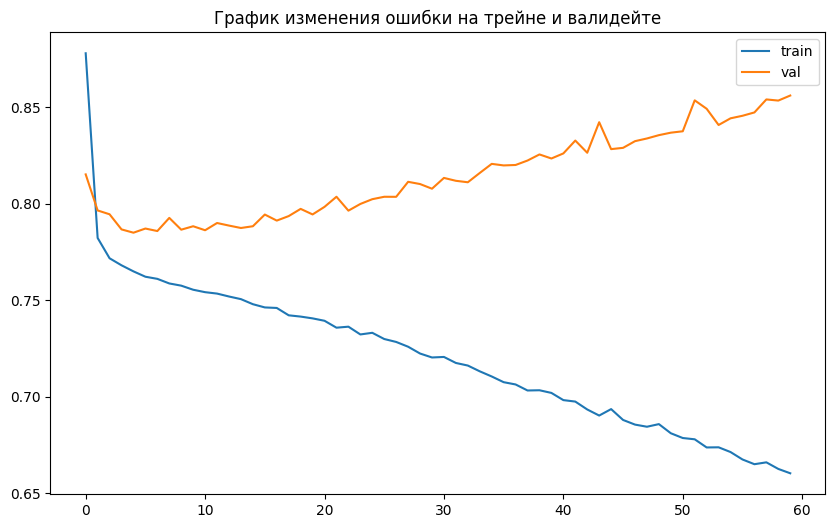

{'train': {'mse': 0.7606749534606934,
  'rmse': 0.8721668124198914,
  'mae': 0.7087922692298889,
  'r2': 0.08090513944625854,
  'corr': np.float64(0.27342322387084333),
  'pair_acc': np.float64(0.5934056030249777),
  'top_recall': np.float64(0.44479233857666145)},
 'test': {'mse': 0.7156805992126465,
  'rmse': 0.8459790945053101,
  'mae': 0.6904793381690979,
  'r2': 0.07703948020935059,
  'corr': np.float64(0.25698209017283513),
  'pair_acc': np.float64(0.619626832688948),
  'top_recall': np.float64(0.4307195329922603)},
 'val': {'mse': 0.7848902344703674,
  'rmse': 0.8859403133392334,
  'mae': 0.7164006233215332,
  'r2': 0.07755774259567261,
  'corr': np.float64(0.22913960451936122),
  'pair_acc': np.float64(0.6038060589087885),
  'top_recall': np.float64(0.46455135773317585)},
 'run_name': 'baseline',
 'best_epoch': 5}

In [26]:

baseline_metrics = evaluate_candidate(
    run_name = "baseline",
    hidden_layers = [64, 32],
    activation = nn.ReLU,
    dropout = 0,
    batchnorm = False,
    optimizer_name = "Adam",
    scheduler_flg = False,
    criterion = nn.MSELoss(),
    lr = best_lr,
    wd = best_wd,
    early_stopping_patience = None
)
baseline_metrics


2026/06/14 23:35:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 23:35:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 23:35:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

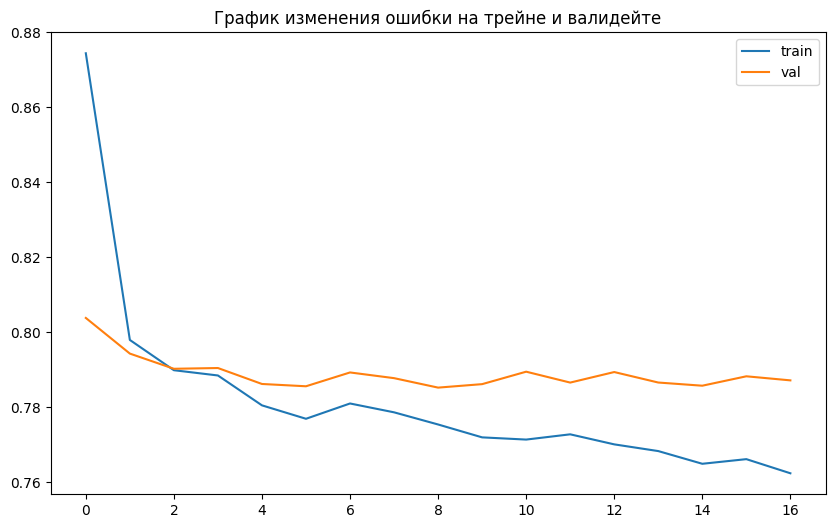

{'train': {'mse': 0.7560877203941345,
  'rmse': 0.8695330619812012,
  'mae': 0.7076552510261536,
  'r2': 0.08644777536392212,
  'corr': np.float64(0.2886794262048842),
  'pair_acc': np.float64(0.5991786822984468),
  'top_recall': np.float64(0.4552691751333803)},
 'test': {'mse': 0.7146093845367432,
  'rmse': 0.8453457355499268,
  'mae': 0.6913830637931824,
  'r2': 0.07842087745666504,
  'corr': np.float64(0.2497064177724234),
  'pair_acc': np.float64(0.6161280514842166),
  'top_recall': np.float64(0.41773252000524735)},
 'val': {'mse': 0.7852592468261719,
  'rmse': 0.8861485719680786,
  'mae': 0.7171458601951599,
  'r2': 0.07712411880493164,
  'corr': np.float64(0.22678598330330402),
  'pair_acc': np.float64(0.6045641471030377),
  'top_recall': np.float64(0.4592483274301456)},
 'run_name': 'candidate_1',
 'best_epoch': 9}

In [27]:


candidate1_metrics = evaluate_candidate(
    run_name = "candidate_1",
    hidden_layers = [128, 64, 32],
    activation = nn.ReLU,
    dropout = 0.3,
    batchnorm = False,
    optimizer_name = "Adam",
    scheduler_flg = False,
    criterion = nn.MSELoss(),
    lr = best_lr,
    wd = best_wd,
    early_stopping_patience = 8
)
candidate1_metrics



2026/06/14 23:35:49 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 23:35:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 23:35:54 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

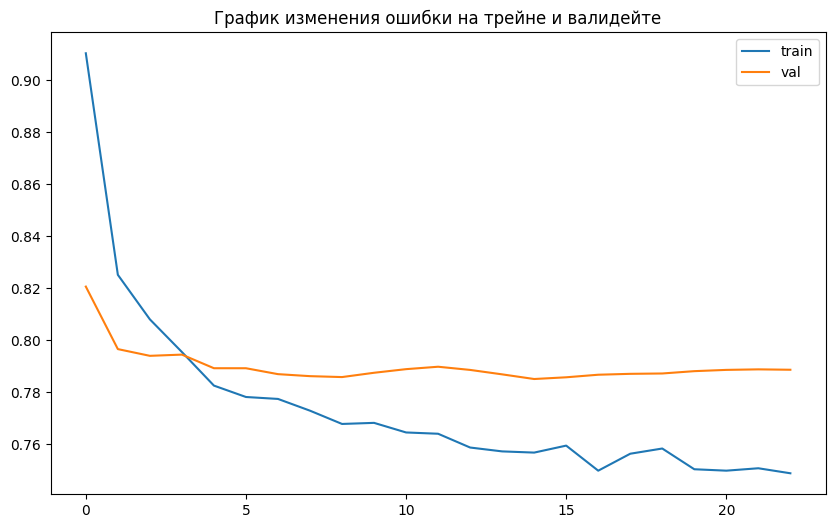

{'train': {'mse': 0.7348361611366272,
  'rmse': 0.8572258353233337,
  'mae': 0.6975545287132263,
  'r2': 0.11212527751922607,
  'corr': np.float64(0.3172286597372043),
  'pair_acc': np.float64(0.6084913902430223),
  'top_recall': np.float64(0.47292674078676195)},
 'test': {'mse': 0.7144153714179993,
  'rmse': 0.8452309370040894,
  'mae': 0.6903844475746155,
  'r2': 0.07867109775543213,
  'corr': np.float64(0.24826582125342453),
  'pair_acc': np.float64(0.6146567129447805),
  'top_recall': np.float64(0.4626820149547422)},
 'val': {'mse': 0.7851417660713196,
  'rmse': 0.8860822319984436,
  'mae': 0.7172765731811523,
  'r2': 0.07726216316223145,
  'corr': np.float64(0.2345853359025397),
  'pair_acc': np.float64(0.6091568939443216),
  'top_recall': np.float64(0.44788469106650913)},
 'run_name': 'candidate_2',
 'best_epoch': 15}

In [28]:


candidate2_metrics = evaluate_candidate(
    run_name = "candidate_2",
    hidden_layers = [128, 64, 32],
    activation = nn.GELU,
    dropout = 0.2,
    batchnorm = True,
    optimizer_name = "AdamW",
    scheduler_flg = True,
    criterion = nn.MSELoss(),
    lr = best_lr,
    wd = best_wd,
    early_stopping_patience = 8
)
candidate2_metrics



Всего обучили 3 нейросети:
* бейзлайн модель - без регуляризации, умной настройки шага обучения, без ранней остновки - нужна, чтобы сравнить с ней моделей кадидатов и сделать вывод, помогли ли использованные приемы
* кандидат 1 - добавляем глубину и ширину нейросети, а также для профилактики переобучения доавбляем отключение случайных нейронов и раннюю остановку
* кандидат 2 - добвляем более гладкую функцию активации, батч-нормализацию (так как есть признаки разных масшиабов), адаптивную скорость обучения

Для всех запусков используются вычисленные на валидационной выброке lr и weight_decay

По графикам ошибок можем заметить, что бейзлайн модель ожмдаемо переобучается, 1-ый кандидат предотвращает переобучние засчет выкидывания случайных нейронов и ранней остановки, а у 2-го кандидата ошибка на валидационной выборке почти сразу стабилизируется

In [29]:

result = pd.DataFrame({
    "baseline": baseline_metrics["test"],
    "candidate_1": candidate1_metrics["test"],
    "candidate_2": candidate2_metrics["test"]
})
result


,baseline,candidate_1,candidate_2
mse,0.715681,0.714609,0.714415
rmse,0.845979,0.845346,0.845231
mae,0.690479,0.691383,0.690384
r2,0.077039,0.078421,0.078671
corr,0.256982,0.249706,0.248266
pair_acc,0.619627,0.616128,0.614657
top_recall,0.430720,0.417733,0.462682


Видим, что по среднему качеству модели очень похожи, но по показателю полезности топ 10% отвзывов заметно лидирует 2-ой кандидат, поэтому в качестве лучшей модели выбираем именно его

Это, по сути главное в данной безнес задаче, - чтобы в топе отображалось как можно больше полезных отзывов

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
